In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(42)
np.random.seed(42)

print("Using device:", device)

Using device: cuda


In [2]:
tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_set = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=tf
)

val_set = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=tf
)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = DataLoader(val_set, batch_size=256, shuffle=False)

print("Train samples:", len(train_set))
print("Validation samples:", len(val_set))

100.0%
100.0%
100.0%
100.0%

Train samples: 60000
Validation samples: 10000


In [3]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel min/max:", images.min().item(), images.max().item())
print("First labels:", labels[:10].tolist())

Image batch shape: torch.Size([128, 1, 28, 28])
Label batch shape: torch.Size([128])
Pixel min/max: -1.0 1.0
First labels: [5, 7, 4, 7, 3, 8, 9, 5, 3, 1]


In [4]:
model = nn.Sequential(
    nn.Flatten(),

    nn.Linear(784, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(p=0.3),

    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(p=0.3),

    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),

    nn.Linear(64, 10)
).to(device)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (3): ReLU()
  (4): Dropout(p=0.3, inplace=False)
  (5): Linear(in_features=256, out_features=128, bias=True)
  (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (7): ReLU()
  (8): Dropout(p=0.3, inplace=False)
  (9): Linear(in_features=128, out_features=64, bias=True)
  (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (11): ReLU()
  (12): Linear(in_features=64, out_features=10, bias=True)
)


In [5]:
epochs = 15

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs
)

In [6]:
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * images.size(0)

            predictions = logits.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

In [7]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
    model.train()

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

    scheduler.step()

    train_loss, train_acc = evaluate(model, train_loader, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 01/15 | Train Loss: 0.3792 | Val Loss: 0.4226 | Train Acc: 0.8649 | Val Acc: 0.8500
Epoch 02/15 | Train Loss: 0.3258 | Val Loss: 0.3764 | Train Acc: 0.8808 | Val Acc: 0.8632
Epoch 03/15 | Train Loss: 0.2928 | Val Loss: 0.3549 | Train Acc: 0.8929 | Val Acc: 0.8700
Epoch 04/15 | Train Loss: 0.2867 | Val Loss: 0.3526 | Train Acc: 0.8951 | Val Acc: 0.8723
Epoch 05/15 | Train Loss: 0.2541 | Val Loss: 0.3282 | Train Acc: 0.9054 | Val Acc: 0.8798
Epoch 06/15 | Train Loss: 0.2473 | Val Loss: 0.3254 | Train Acc: 0.9080 | Val Acc: 0.8815
Epoch 07/15 | Train Loss: 0.2301 | Val Loss: 0.3155 | Train Acc: 0.9154 | Val Acc: 0.8869
Epoch 08/15 | Train Loss: 0.2260 | Val Loss: 0.3172 | Train Acc: 0.9159 | Val Acc: 0.8845
Epoch 09/15 | Train Loss: 0.2117 | Val Loss: 0.3049 | Train Acc: 0.9214 | Val Acc: 0.8887
Epoch 10/15 | Train Loss: 0.2020 | Val Loss: 0.3022 | Train Acc: 0.9252 | Val Acc: 0.8899
Epoch 11/15 | Train Loss: 0.1919 | Val Loss: 0.3009 | Train Acc: 0.9302 | Val Acc: 0.8925
Epoch 12/1

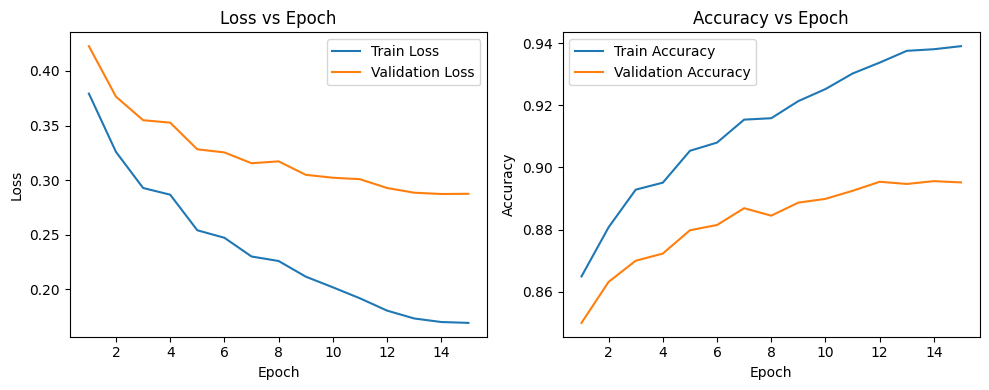

Best validation accuracy: 0.8956
Best epoch: 14


In [9]:
epoch_range = range(1, epochs + 1)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epoch_range, train_losses, label="Train Loss")
plt.plot(epoch_range, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epoch_range, train_accs, label="Train Accuracy")
plt.plot(epoch_range, val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()

plt.tight_layout()
plt.show()

best_val_acc = max(val_accs)
best_epoch = val_accs.index(best_val_acc) + 1

print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Best epoch: {best_epoch}")

The training and validation curves improve steadily throughout the 15 epochs, with both training and validation loss decreasing over time while accuracy increases. The validation curves remain relatively close to the training curves, suggesting that the model generalises reasonably well without severe overfitting, although a small gap appears near the end of training. The best validation accuracy achieved was **89.56%**, reached at epoch **14**.